# 06 — EDA: Zero Demand, Prices, Events, SNAP, and Outliers

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook completes the short EDA series. It uses **training targets only** to describe zero demand, price bands, event weeks, SNAP weeks, and flagged outliers. The comparisons are descriptive and do not prove causation.

## 1. Load train-only fields

The Parquet filter is applied before loading. Validation and test targets are not read.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as pads
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "m5_foods_weekly").exists():
            return candidate.resolve()
    raise FileNotFoundError("Processed FOODS data was not found. Run notebooks 01 and 02 first.")

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_weekly"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)
dataset = pads.dataset(PROCESSED_DIR, format="parquet")
train_filter = pads.field("dataset_split") == "train"
columns = [
    "weekly_units_sold", "sell_price_mean", "event_days", "event_names",
    "snap_days", "has_sales_outlier", "sales_outlier_days",
]
train_table = dataset.to_table(columns=columns, filter=train_filter)
train_table = train_table.append_column("is_zero_week", pc.equal(train_table["weekly_units_sold"], 0))
train_table = train_table.append_column("has_event", pc.greater(train_table["event_days"], 0))
train_table = train_table.append_column("has_snap", pc.greater(train_table["snap_days"], 0))

print("Train rows loaded:", f"{train_table.num_rows:,}")
print("Validation/test targets loaded: no")

Train rows loaded: 3,003,902
Validation/test targets loaded: no


## 2. Zero-demand weeks

A zero is a valid observation, not a missing value. Its frequency matters because intermittent demand is harder to forecast than continuous demand.

In [2]:
zero_count = pc.sum(train_table["is_zero_week"]).as_py()
positive_count = train_table.num_rows - zero_count
zero_summary = pd.DataFrame([
    {"demand_status": "zero demand", "rows": zero_count, "share_pct": 100 * zero_count / train_table.num_rows},
    {"demand_status": "positive demand", "rows": positive_count, "share_pct": 100 * positive_count / train_table.num_rows},
])
display(zero_summary)

,demand_status,rows,share_pct
0,zero demand,622343,20.718
1,positive demand,2381559,79.282


## 3. Events and SNAP

These comparisons measure association only. Event and SNAP weeks also differ by date, store, product, and season, so the difference cannot be interpreted as a causal effect.

In [3]:
event_summary = train_table.group_by("has_event").aggregate([
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "sum"),
    ("is_zero_week", "sum"),
]).to_pandas().rename(columns={
    "weekly_units_sold_count": "rows",
    "weekly_units_sold_mean": "mean_weekly_units",
    "weekly_units_sold_sum": "total_units",
    "is_zero_week_sum": "zero_demand_weeks",
})
event_summary["group"] = np.where(event_summary["has_event"], "event week", "no event")
event_summary["zero_demand_pct"] = 100 * event_summary["zero_demand_weeks"] / event_summary["rows"]

snap_summary = train_table.group_by("has_snap").aggregate([
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "sum"),
    ("is_zero_week", "sum"),
]).to_pandas().rename(columns={
    "weekly_units_sold_count": "rows",
    "weekly_units_sold_mean": "mean_weekly_units",
    "weekly_units_sold_sum": "total_units",
    "is_zero_week_sum": "zero_demand_weeks",
})
snap_summary["group"] = np.where(snap_summary["has_snap"], "SNAP week", "no SNAP")
snap_summary["zero_demand_pct"] = 100 * snap_summary["zero_demand_weeks"] / snap_summary["rows"]

event_names_summary = train_table.group_by("event_names").aggregate([
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "mean"),
]).to_pandas().rename(columns={
    "weekly_units_sold_count": "rows",
    "weekly_units_sold_mean": "mean_weekly_units",
}).sort_values("rows", ascending=False).reset_index(drop=True)

display(event_summary[["group", "rows", "mean_weekly_units", "zero_demand_pct"]])
display(snap_summary[["group", "rows", "mean_weekly_units", "zero_demand_pct"]])
display(event_names_summary.head(12))

,group,rows,mean_weekly_units,zero_demand_pct
0,event week,1453355,14.798,20.685
1,no event,1550547,14.670,20.749


,group,rows,mean_weekly_units,zero_demand_pct
0,SNAP week,1846490,15.265,20.473
1,no SNAP,1157412,13.882,21.108


,event_names,rows,mean_weekly_units
0,No event,1550547,14.670
1,SuperBowl,64825,15.186
2,StPatricksDay,60192,14.189
3,MartinLutherKingDay,58733,13.258
4,OrthodoxChristmas,58391,15.337
5,Thanksgiving,57602,12.319
6,Halloween,57420,14.004
7,LaborDay,56255,16.572
8,Eid al-Fitr,55836,15.761
9,IndependenceDay,55126,16.634


## 4. Price bands

Prices are divided into training-data quartiles. Different price bands contain different products, so this chart is descriptive and is not a price-elasticity estimate.

In [4]:
price_demand = train_table.select(["sell_price_mean", "weekly_units_sold", "is_zero_week"]).to_pandas()
price_demand["price_band"], price_edges = pd.qcut(
    price_demand["sell_price_mean"],
    q=4,
    labels=["Q1 lowest", "Q2", "Q3", "Q4 highest"],
    retbins=True,
    duplicates="drop",
)
price_summary = price_demand.groupby("price_band", observed=True).agg(
    rows=("weekly_units_sold", "size"),
    minimum_price=("sell_price_mean", "min"),
    maximum_price=("sell_price_mean", "max"),
    mean_weekly_units=("weekly_units_sold", "mean"),
    zero_demand_weeks=("is_zero_week", "sum"),
).reset_index()
price_summary["zero_demand_pct"] = 100 * price_summary["zero_demand_weeks"] / price_summary["rows"]
display(price_summary)
del price_demand

,price_band,rows,minimum_price,maximum_price,mean_weekly_units,zero_demand_weeks,zero_demand_pct
0,Q1 lowest,883935,0.050,1.980,27.225,145016,16.406
1,Q2,662777,1.983,2.680,10.302,168122,25.366
2,Q3,708336,2.683,3.970,9.509,140962,19.900
3,Q4 highest,748854,3.973,19.480,8.846,168243,22.467


## 5. Flagged outliers

Outlier weeks were retained during cleaning. The flag identifies weeks containing at least one daily sale above the training audit threshold; it does not label them as incorrect.

In [5]:
outlier_summary = train_table.group_by("has_sales_outlier").aggregate([
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "max"),
    ("sales_outlier_days", "sum"),
]).to_pandas().rename(columns={
    "weekly_units_sold_count": "rows",
    "weekly_units_sold_mean": "mean_weekly_units",
    "weekly_units_sold_max": "maximum_weekly_units",
    "sales_outlier_days_sum": "flagged_daily_values",
})
outlier_summary["group"] = np.where(outlier_summary["has_sales_outlier"].eq(1), "flagged week", "not flagged")
outlier_summary["share_pct"] = 100 * outlier_summary["rows"] / train_table.num_rows
display(outlier_summary[["group", "rows", "share_pct", "mean_weekly_units", "maximum_weekly_units", "flagged_daily_values"]])

,group,rows,share_pct,mean_weekly_units,maximum_weekly_units,flagged_daily_values
0,not flagged,2983521,99.322,12.781,316,0
1,flagged week,20381,0.678,300.334,3976,53194


## 6. Visual summary

The four charts show frequency and associations. They are not causal experiments.

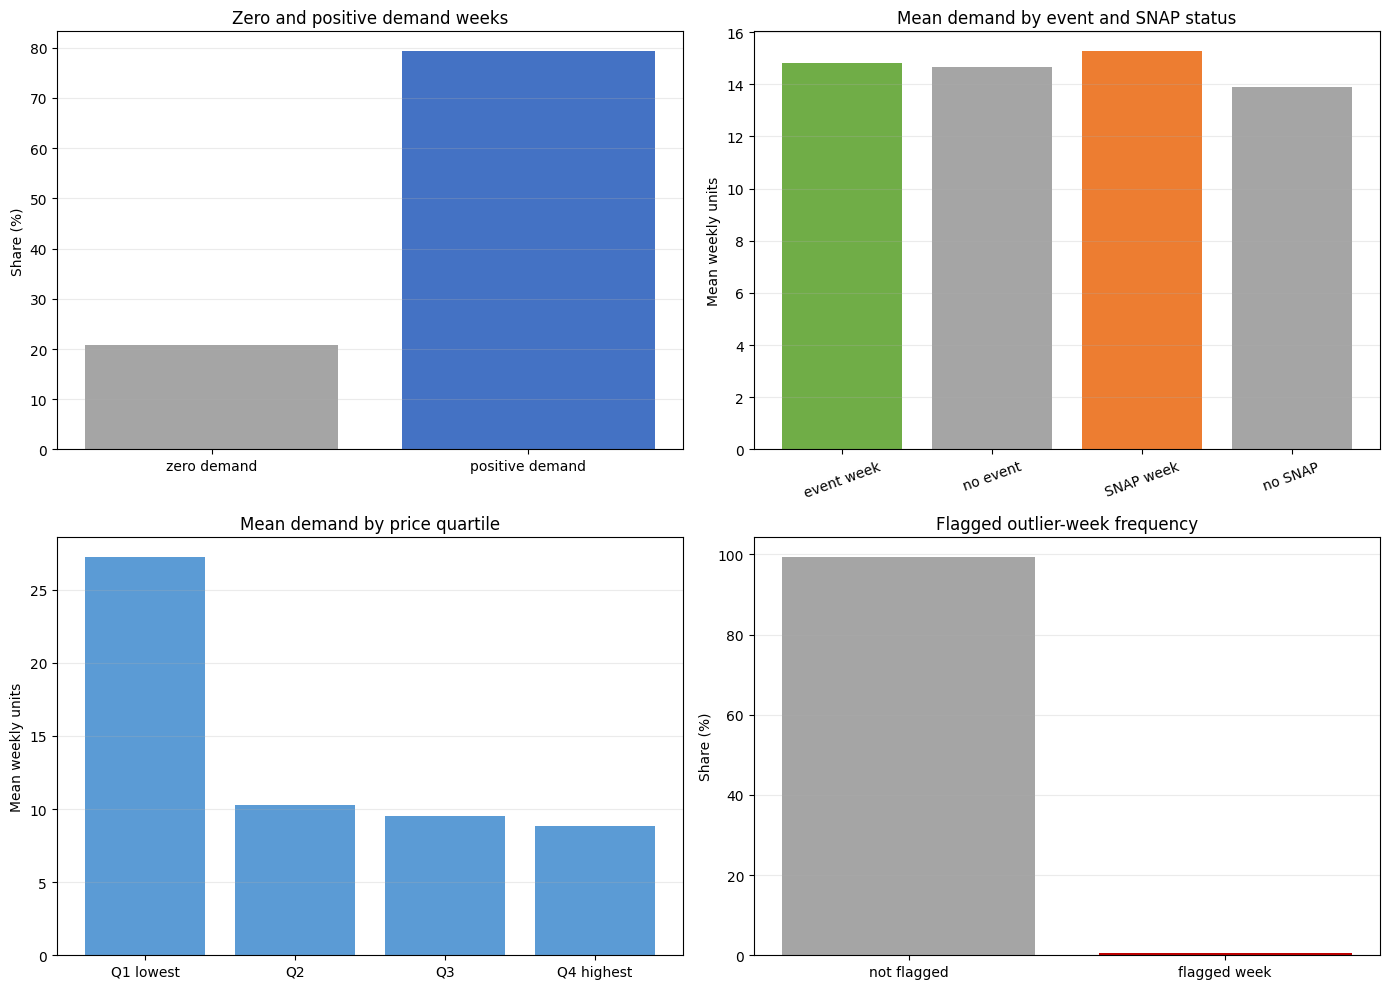

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].bar(zero_summary["demand_status"], zero_summary["share_pct"], color=["#A5A5A5", "#4472C4"])
axes[0, 0].set_title("Zero and positive demand weeks")
axes[0, 0].set_ylabel("Share (%)")

factor_means = pd.concat([
    event_summary[["group", "mean_weekly_units"]],
    snap_summary[["group", "mean_weekly_units"]],
])
axes[0, 1].bar(factor_means["group"], factor_means["mean_weekly_units"], color=["#70AD47", "#A5A5A5", "#ED7D31", "#A5A5A5"])
axes[0, 1].set_title("Mean demand by event and SNAP status")
axes[0, 1].set_ylabel("Mean weekly units")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].bar(price_summary["price_band"].astype(str), price_summary["mean_weekly_units"], color="#5B9BD5")
axes[1, 0].set_title("Mean demand by price quartile")
axes[1, 0].set_ylabel("Mean weekly units")

axes[1, 1].bar(outlier_summary["group"], outlier_summary["share_pct"], color=["#A5A5A5", "#C00000"])
axes[1, 1].set_title("Flagged outlier-week frequency")
axes[1, 1].set_ylabel("Share (%)")

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 7. Reproducible findings and verification

Small reports are saved for GitHub. The checks confirm train-only execution and complete row accounting.

In [7]:
event_rows = event_summary.set_index("group")["rows"].to_dict()
snap_rows = snap_summary.set_index("group")["rows"].to_dict()
flagged = outlier_summary.loc[outlier_summary["group"].eq("flagged week")].iloc[0]
findings = pd.DataFrame([
    {"finding": "zero_demand_share_pct", "value": zero_summary.loc[zero_summary["demand_status"].eq("zero demand"), "share_pct"].iloc[0]},
    {"finding": "event_week_mean_units", "value": event_summary.loc[event_summary["group"].eq("event week"), "mean_weekly_units"].iloc[0]},
    {"finding": "no_event_mean_units", "value": event_summary.loc[event_summary["group"].eq("no event"), "mean_weekly_units"].iloc[0]},
    {"finding": "snap_week_mean_units", "value": snap_summary.loc[snap_summary["group"].eq("SNAP week"), "mean_weekly_units"].iloc[0]},
    {"finding": "no_snap_mean_units", "value": snap_summary.loc[snap_summary["group"].eq("no SNAP"), "mean_weekly_units"].iloc[0]},
    {"finding": "flagged_outlier_week_share_pct", "value": flagged["share_pct"]},
    {"finding": "flagged_daily_values", "value": flagged["flagged_daily_values"]},
])

assert train_table.num_rows == 3_003_902
assert int(zero_summary["rows"].sum()) == train_table.num_rows
assert sum(event_rows.values()) == train_table.num_rows
assert sum(snap_rows.values()) == train_table.num_rows
assert int(price_summary["rows"].sum()) == train_table.num_rows
assert int(outlier_summary["rows"].sum()) == train_table.num_rows
assert not findings.isna().any().any()

zero_summary.to_csv(REPORT_DIR / "eda_zero_demand_train.csv", index=False)
event_summary.to_csv(REPORT_DIR / "eda_event_summary_train.csv", index=False)
snap_summary.to_csv(REPORT_DIR / "eda_snap_summary_train.csv", index=False)
event_names_summary.to_csv(REPORT_DIR / "eda_event_names_train.csv", index=False)
price_summary.to_csv(REPORT_DIR / "eda_price_bands_train.csv", index=False)
outlier_summary.to_csv(REPORT_DIR / "eda_outlier_summary_train.csv", index=False)
findings.to_csv(REPORT_DIR / "eda_quality_factor_findings.csv", index=False)

display(findings)
print("EDA-4 train-only checks passed.")
print("Validation/test targets were not loaded.")

,finding,value
0,zero_demand_share_pct,20.718
1,event_week_mean_units,14.798
2,no_event_mean_units,14.670
3,snap_week_mean_units,15.265
4,no_snap_mean_units,13.882
5,flagged_outlier_week_share_pct,0.678
6,flagged_daily_values,"53,194.000"


EDA-4 train-only checks passed.
Validation/test targets were not loaded.


## 8. Initial interpretation

Zero demand is common enough to require lag-based features and group-level error analysis. Event, SNAP, price-band, and outlier groups show different demand distributions, so these fields are reasonable feature candidates. They must still be evaluated on chronological validation data before being accepted.